In [1]:
import matplotlib.pyplot as plt
import numpy as np

import torch
from torch import nn, optim
from torchvision import datasets, transforms

import zipfile
import ot

import shutil
import os
import pandas as pd

device = ("cuda" if torch.cuda.is_available() else "cpu") # Use GPU or CPU for training

2024-01-20 22:32:20.094743: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2024-01-20 22:32:21.939219: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2024-01-20 22:32:21.939353: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2024-01-20 22:32:21.939481: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-01-20 22:32:21.941090: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:13:00.0 name: NVIDIA A100 80GB PCIe computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 79.15GiB deviceMemoryBandwidth: 1.76TiB/s
2024-01-20 22:32:21.941141: I tensorflow/stream_executor/cuda/cuda_gpu_

In [2]:
'''with zipfile.ZipFile("celeba.zip","r") as zip_ref:
  zip_ref.extractall("data_faces/")'''

'with zipfile.ZipFile("celeba.zip","r") as zip_ref:\n  zip_ref.extractall("data_faces/")'

In [3]:
'''
root = 'data_faces/img_align_celeba'
img_list = os.listdir(root)
print(len(img_list))
     '''

"\nroot = 'data_faces/img_align_celeba'\nimg_list = os.listdir(root)\nprint(len(img_list))\n     "

In [4]:
'''
df = pd.read_csv("list_attr_celeba.csv")
df = df[['image_id', 'Smiling']]'''

'\ndf = pd.read_csv("list_attr_celeba.csv")\ndf = df[[\'image_id\', \'Smiling\']]'

In [5]:
# to make directories

'''!rm -rf data
!mkdir data && mkdir data/smile && mkdir data/no_smile'''

'!rm -rf data\n!mkdir data && mkdir data/smile && mkdir data/no_smile'

In [6]:
'''
s0 = 0
s1 = 0

num = 200000

for i, (_, i_row) in enumerate(df.iterrows()):
  if s0 < num:
    if i_row['Smiling'] == 1:
      s0 += 1
      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/smile/' + i_row['image_id'])
  
  if s1 < num:
    if i_row['Smiling'] == -1:
      s1 += 1
      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/no_smile/' + i_row['image_id'])
  
  if s0 == num and s1 == num:
    break'''

"\ns0 = 0\ns1 = 0\n\nnum = 200000\n\nfor i, (_, i_row) in enumerate(df.iterrows()):\n  if s0 < num:\n    if i_row['Smiling'] == 1:\n      s0 += 1\n      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/smile/' + i_row['image_id'])\n  \n  if s1 < num:\n    if i_row['Smiling'] == -1:\n      s1 += 1\n      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/no_smile/' + i_row['image_id'])\n  \n  if s0 == num and s1 == num:\n    break"

In [7]:
'''
img_list = os.listdir('data_cel/smile/')
img_list.extend(os.listdir('data_cel/no_smile/'))'''

"\nimg_list = os.listdir('data_cel/smile/')\nimg_list.extend(os.listdir('data_cel/no_smile/'))"

In [8]:
'''print("Images: ", len(img_list))
'''

'print("Images: ", len(img_list))\n'

In [9]:
'''transform = transforms.Compose([
          transforms.Resize((64, 64)),
          transforms.ToTensor()
          ])

batch_size = 64
celeba_data = datasets.ImageFolder('data_cel', transform=transform)'''

"transform = transforms.Compose([\n          transforms.Resize((64, 64)),\n          transforms.ToTensor()\n          ])\n\nbatch_size = 64\nceleba_data = datasets.ImageFolder('data_cel', transform=transform)"

In [10]:
'''print(celeba_data.classes)
print(len(celeba_data))'''

'print(celeba_data.classes)\nprint(len(celeba_data))'

In [11]:
'''
train_set, test_set = torch.utils.data.random_split(celeba_data, [int(len(img_list) * 0.75), len(img_list) - int(len(img_list) * 0.75)])
train_data_size = len(train_set)
test_data_size = len(test_set)'''

'\ntrain_set, test_set = torch.utils.data.random_split(celeba_data, [int(len(img_list) * 0.75), len(img_list) - int(len(img_list) * 0.75)])\ntrain_data_size = len(train_set)\ntest_data_size = len(test_set)'

In [12]:
'''trainLoader = torch.utils.data.DataLoader(train_set,batch_size=batch_size, shuffle=True)
testLoader  = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=True)
'''

'trainLoader = torch.utils.data.DataLoader(train_set,batch_size=batch_size, shuffle=True)\ntestLoader  = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=True)\n'

In [13]:
'''

print(train_data_size)
print(test_data_size)'''

'\n\nprint(train_data_size)\nprint(test_data_size)'

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from vae import VAE, VAE_big

In [15]:
image_channels = 3

print('image_channels', image_channels)

#model = VAE(image_channels=image_channels).to(device)

model = VAE_big(image_channels=image_channels).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) 

image_channels 3


In [16]:
def loss_fn(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, size_average=False)
    KLD = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD, BCE, KLD

def get_kl_divergences(mu_so, std_so, mu_po, std_po):
    dists = torch.tensor([]).to(device)
    for i in range(64):
        mu_po_n = mu_po[i]
        std_po_n = std_po[i]
        distances = 0.5 * torch.sum (((mu_so - mu_po_n)**2 / std_po_n**2) + (std_so**2 / std_po_n**2) - 1 - torch.log(std_so) + torch.log(std_po_n))
        #print(distances.item())
        dists = torch.cat([dists, distances.unsqueeze(0)])
    return dists

def give_mean_sliced_wass_dist(allChImage1, allChImage2):
    mean_wass = 0
    for i in range(3):
        wassDistance = ot.sliced_wasserstein_distance(allChImage1[i], allChImage2[i], seed=0)  
        mean_wass = mean_wass + wassDistance
    return mean_wass/3

In [17]:
model = VAE_big(image_channels=image_channels).to(device)

train_data_size = 105000
epochs = 200
model.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_celebA/celebA_CNN_VAE_big_trainSize'+str(train_data_size)+'_epochs'+str(epochs)+'.torch'))

# Set the model to evaluation mode (if needed)
model.eval()

VAE_big(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2))
    (9): ReLU()
    (10): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(4, 4), stride=(2, 2))
    (13): ReLU()
    (14): Flatten()
  )
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=1024, bias=True)
  (decoder): Sequential(
    (0): UnFlatten()
    (1): ConvTranspose2d(1024, 256, kernel_size=(5, 5), stride=(2, 2))
    (2): ReLU()
    (3): ConvTranspose2d(256, 128, kern

###### How to calculate KL divergence when you have a multivariate Gaussian

KL_cur = 0.5 * torch.sum (((mu_so - mu_po)**2 / std_po**2) + (std_so**2 / std_po**2) - 1 - torch.log(std_so) + torch.log(std_po))


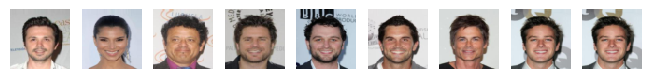

In [18]:
test_ne = torch.load("/home/luser/autoencoder_attacks/train_aautoencoders/celeb_neighbours/neighbours13.pt")

with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(1, 11,i+1)
        #plt.imshow(scale_noised_images[i][0].cpu().numpy())
        plt.imshow(test_ne[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')

        plt.axis('off')
    plt.show()

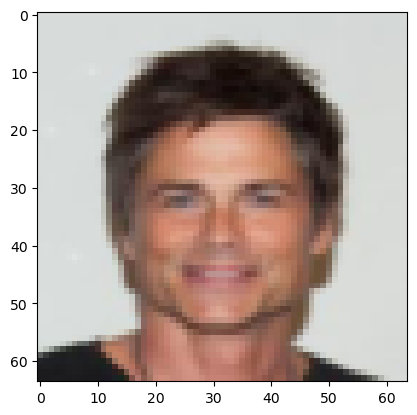

In [19]:
plt.imshow(test_ne[-3].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')


In [20]:
source_im = test_ne[-1].unsqueeze(0)
target_im = test_ne[-3].unsqueeze(0)
source_im.shape, target_im.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1, 3, 64, 64]))

In [21]:
# Load the autonoiser

from models import AE, CNN_AE_fmnist, Autoencoder_linear_contra_fmnist, MLP_VAE_fmnist, CNN_VAE_fmnist, CNN_AE_fmnist_noiser, CNN_AE_fmnist_noiser_sig, CNN_AE_fmnist_noiser_2sig, CNN_AE_fmnist_noiser_2sig_big
latent_dim = 4
no_channels = 3
activation_cnn_noiser = activation_cnn_noiser = nn.ReLU()

autoenoiser_cnn = CNN_AE_fmnist_noiser_2sig_big(latent_dim, no_channels, activation_cnn_noiser).to(device)
criterion = nn.MSELoss()
import torch.optim as optim
optimizer = optim.Adam(autoenoiser_cnn.parameters(), lr=0.0001)

adv_alpha = 0.85
noiser_epochs = 100000

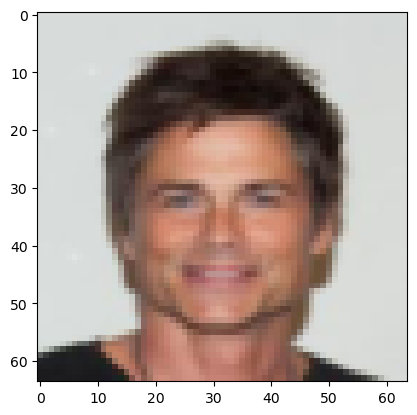

In [22]:
plt.imshow(target_im[0].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')


In [23]:
train_loss = []

for epoch in range(noiser_epochs):
    #t_i = 0
    # training our model
    #for idx, (image, label) in enumerate(trainLoader):
    #images, label = image.to(device), label.to(device)
    #print("images.shape", images.shape)
    images = source_im
    optimizer.zero_grad()
    data = images.to(device)
    noise_outputs = autoenoiser_cnn(data)
    noise_outputs = (noise_outputs - 1.0)*2.0
    adv_gen_enc = model.fc1(model.encoder(data + noise_outputs))
    adv_gen,_,_ = model(data + noise_outputs)

    #ae_perturbed_embeds = model_cnnvae_.encoder(adv_gen) # some confusion here. Why are you doin whatever you doing . Should not the input be  data + noise_outputs ?
    ae_perturbed_embeds = model.encoder(data + noise_outputs) # some confusion here. Why are you doin whatever you doing . Should not the input be  data + noise_outputs ?
    mu1, logvar1 = model.fc1(ae_perturbed_embeds), model.fc2(ae_perturbed_embeds)
    std1 = logvar1.mul(0.5).exp_()
    esp1 = torch.randn(*mu1.size()).to(device)
    z1 = mu1 + std1 * esp1

    #train_embeds = model_cnnvae_.encoder(adv_batches[t_i].to(device))
    train_embeds = model.encoder(data.to(device))
    mu2, logvar2 = model.fc1(train_embeds), model.fc2(train_embeds)
    std2 = logvar2.mul(0.5).exp_()
    esp2 = torch.randn(*mu2.size()).to(device)
    z2 = mu2 + std2 * esp2


    adv_gen_loss = criterion(mu1, mu2) + criterion(std1, std2) 

    #print("adv_gen.shape", adv_gen.shape)
    #print("data.shape", data.shape)
    
    fooled_out= model(adv_gen)
    adv_embeds = model.encoder(adv_gen.to(device))
    mu3, logvar3 = model.fc1(adv_embeds), model.fc2(adv_embeds)
    std3 = logvar3.mul(0.5).exp_()
    esp3 = torch.randn(*mu3.size()).to(device)
    z3 = mu3 + std3 * esp3


    target_embeds = model.encoder(target_im.to(device))
    mu4, logvar4 = model.fc1(target_embeds), model.fc2(target_embeds)
    std4 = logvar4.mul(0.5).exp_()
    esp4 = torch.randn(*mu4.size()).to(device)
    z4 = mu4 + std4 * esp4


    #loss = criterion(adv_embeds, target_embeds)
    loss = ( criterion(mu3, mu4) + criterion(std3, std4) )

    #total_loss = loss * (1.0-adv_alpha)  + adv_gen_loss * adv_alpha
    
    total_loss = ( adv_gen_loss * (1.0-adv_alpha) ) + (loss * adv_alpha)
    total_loss.backward()
    optimizer.step()
    
    #t_i +=1

    print(f'Epoch [{epoch+1}/{noiser_epochs}], Loss: {total_loss.item():.4f}')
# save the model
#torch.save(autoenoiser_cnn.state_dict(), '/home/luser/representation-learning-of-unbalanced-datasets/saved_noiser_single_models_with_2sigmoid_mult/model_sp_autoenoiser_'+str(adv_alpha)+'_cnn_class_'+str(input_class)+'_to_class_'+str(target_class)+'adv_class'+str(adv_class)+'')

#torch.save(autoenoiser_cnn.state_dict(), '/home/luser/autoencoder_attacks/saved_noiser_single_models_with_2sigmoid_mult/targetNoiser_vae_celebA_advAlpha'+str(adv_alpha)+'_')

RuntimeError: CUDA error: CUBLAS_STATUS_ALLOC_FAILED when calling `cublasCreate(handle)`

In [28]:
# load the autonoiser

autoenoiser_cnn.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_noiser_single_models_with_2sigmoid_mult/targetNoiser_vae_celebA_advAlpha'+str(adv_alpha)+'_'))

# Set the model to evaluation mode (if needed)
autoenoiser_cnn.eval()

CNN_AE_fmnist_noiser_2sig_big(
  (input_layer): Conv2d(3, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 16, kernel_size=(8, 8), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(16, 8, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
    (7): Flatten(start_dim=1, end_dim=-1)
    (8): Linear(in_features=32, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(8, 2, 2))
    (2): ConvTranspose2d(8, 16, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 32, kernel_size=(8, 8), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding

In [25]:

viz_train = images.reshape(-1, 3, 64, 64).to(device)
#viz_adv = images.reshape(-1, 1, 64, 64).to(device)

In [26]:
viz_train.shape

torch.Size([1, 3, 64, 64])

In [50]:
num_steps = 200
path = torch.linspace(0.0, 3.0, num_steps).to(device)

nth_image_ind = 0


#for nth_image_ind in range(viz_train.shape[0]):

n_th_image = viz_train[nth_image_ind].unsqueeze(0)
#n_th_adv_image = viz_adv[nth_image_ind].unsqueeze(0)

print(n_th_image.shape)
noise_outputs = autoenoiser_cnn(n_th_image)
noise_outputs = (noise_outputs - 1.0)*2.0

so_many_zeros = torch.zeros(num_steps, 3, 64, 64).to(device)
scales = so_many_zeros + path.view(num_steps, 1, 1, 1)  

scaled_noises = noise_outputs * scales

scale_noised_images = n_th_image + scaled_noises

adv_gen,_,_ = model(scale_noised_images)
#print("adv_gen.shape", adv_gen.shape)
#print("n_th_image.shape", n_th_image.shape)

#diff = torch.sqrt((adv_gen - n_th_image)**2)
each_adv_gen_mse = torch.sqrt((adv_gen - n_th_image)**2).mean(dim=(2, 3), keepdim=True).squeeze()
#print("each_adv_gen_mse.shape", each_adv_gen_mse.shape)
fooled_out, _, _= model(adv_gen)

each_fooled_out_mse = torch.sqrt((fooled_out - n_th_image)**2).mean(dim=(2, 3), keepdim=True).squeeze()

'''bool_mix = (each_adv_gen_mse < 0.1) * (each_fooled_out_mse < 0.1)

    if(True in bool_mix):
        print("bool_mix ", bool_mix )
        critical_inds_list.append(nth_image_ind)
        plt.scatter(each_adv_gen_mse.cpu().detach().numpy(), each_fooled_out_mse.cpu().detach().numpy())'''

torch.Size([1, 3, 64, 64])


'bool_mix = (each_adv_gen_mse < 0.1) * (each_fooled_out_mse < 0.1)\n\n    if(True in bool_mix):\n        print("bool_mix ", bool_mix )\n        critical_inds_list.append(nth_image_ind)\n        plt.scatter(each_adv_gen_mse.cpu().detach().numpy(), each_fooled_out_mse.cpu().detach().numpy())'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

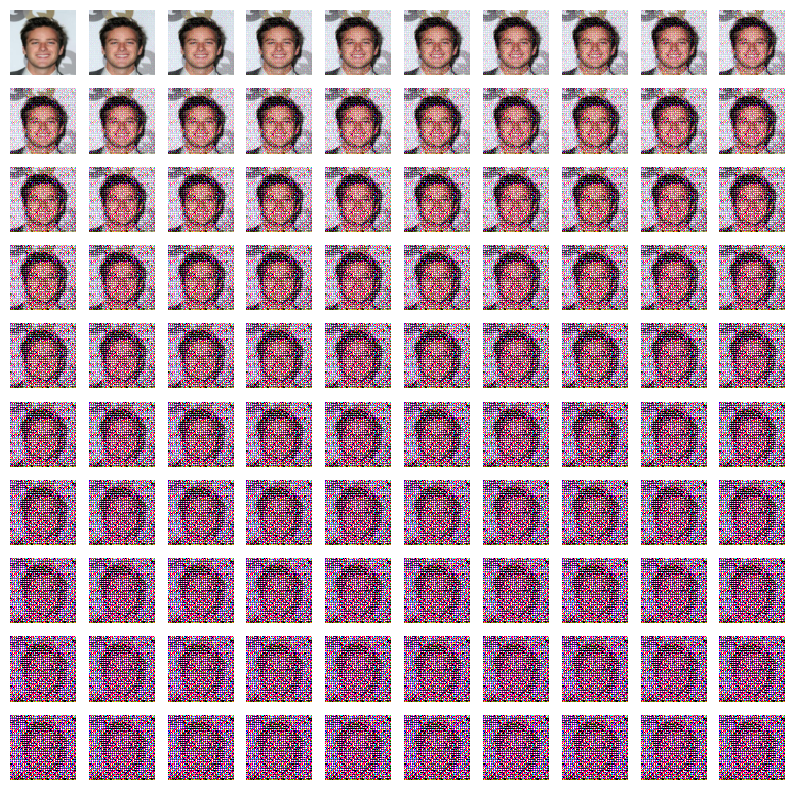

In [51]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(scale_noised_images[i][0].cpu().numpy())
        plt.imshow(scale_noised_images[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')

        plt.axis('off')
    plt.show()

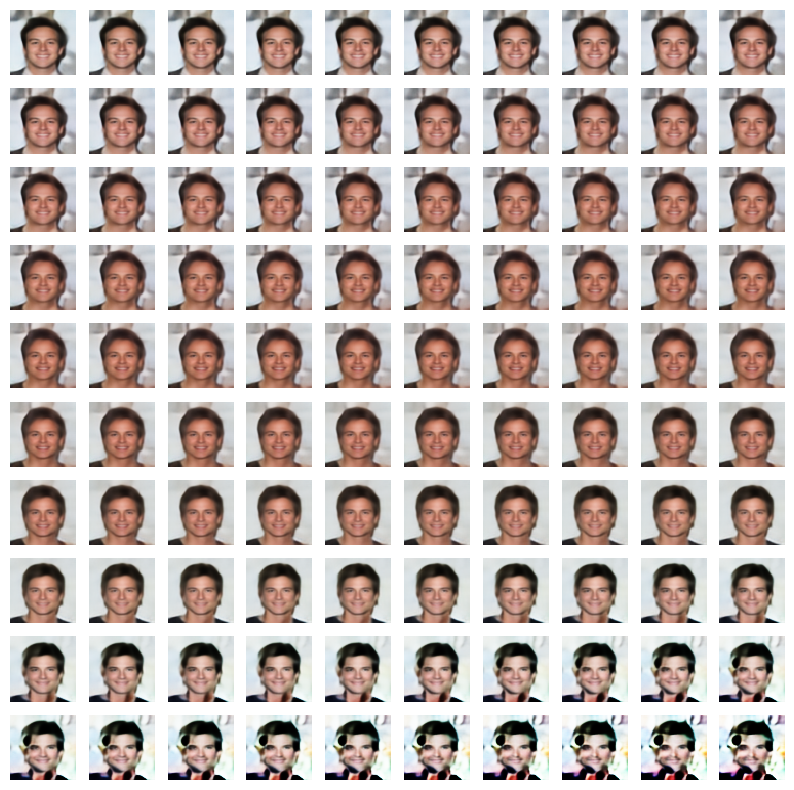

In [52]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(scale_noised_images[i][0].cpu().numpy())
        plt.imshow(adv_gen[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')

        plt.axis('off')
    plt.show()

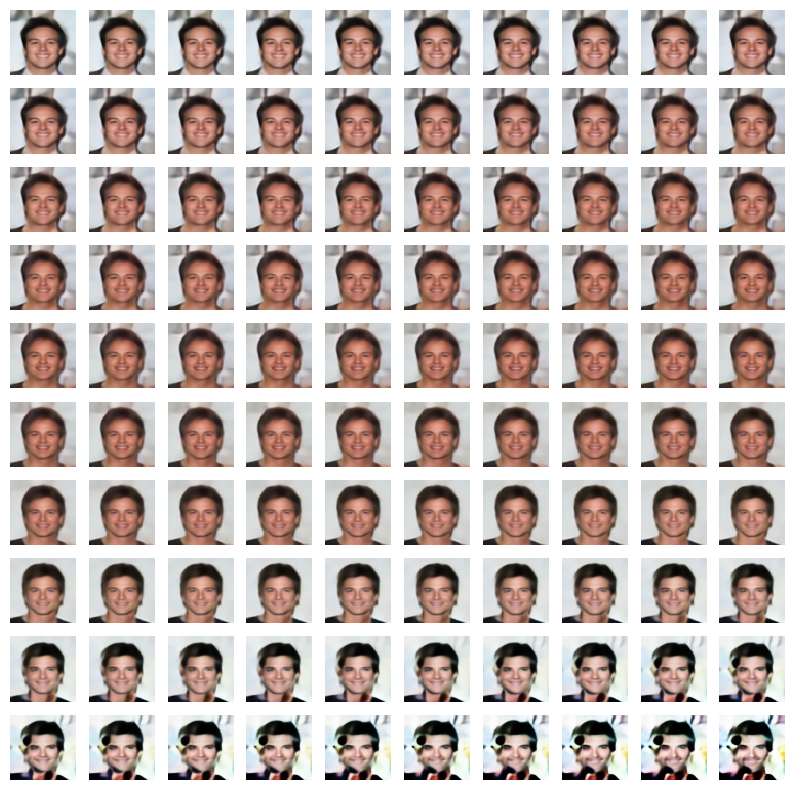

In [53]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(scale_noised_images[i][0].cpu().numpy())
        plt.imshow(fooled_out[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')

        plt.axis('off')
    plt.show()

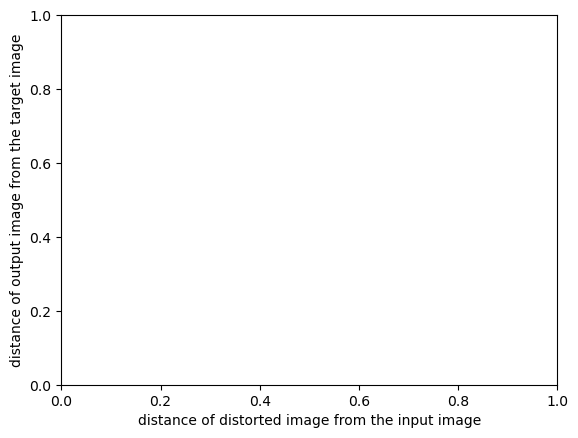

In [54]:
num_steps = 200
path = torch.linspace(0.0, 1.0, num_steps).to(device)

nth_image_ind = 0

critical_inds_list = []

all_selected_adv_gens = torch.tensor([]).to(device)
all_selected_scale_noised_images = torch.tensor([]).to(device)
all_selected_n_th_image = torch.tensor([]).to(device)

for nth_image_ind in range(viz_train.shape[0]):

    n_th_image = viz_train[nth_image_ind].unsqueeze(0)
    #n_th_adv_image = viz_adv[nth_image_ind].unsqueeze(0)


    noise_outputs = autoenoiser_cnn(n_th_image)
    noise_outputs = (noise_outputs - 1.0)*2.0

    so_many_zeros = torch.zeros(num_steps, 3, 64, 64).to(device)
    scales = so_many_zeros + path.view(num_steps, 1, 1, 1)  

    scaled_noises = noise_outputs * scales

    scale_noised_images = n_th_image + scaled_noises
    n_th_image_trick = n_th_image + scaled_noises*0.0
    adv_gen,_,_ = model(scale_noised_images)

    
    #diff = torch.sqrt((adv_gen - n_th_image)**2)
    each_adv_gen_mse = torch.sqrt((adv_gen - n_th_image)**2).mean(dim=(1, 2, 3), keepdim=True).squeeze()
    #each_adv_gen_mse = torch.sqrt((adv_gen - adv_gen[0].unsqueeze(0))**2).mean(dim=(2, 3), keepdim=True).squeeze()
    #print("each_adv_gen_mse.shape", each_adv_gen_mse.shape)
    fooled_out, _, _= model(adv_gen)

    #each_fooled_out_mse = torch.sqrt((fooled_out - adv_gen)**2).mean(dim=(2, 3), keepdim=True).squeeze()
    each_fooled_out_mse = torch.sqrt((fooled_out - n_th_image)**2).mean(dim=(1, 2, 3), keepdim=True).squeeze()
    #each_fooled_out_mse = torch.sqrt((fooled_out - fooled_out[-1].unsqueeze(0))**2).mean(dim=(2, 3), keepdim=True).squeeze()
    #print("each_fooled_out_mse.max(), each_fooled_out_mse.min()", each_fooled_out_mse.max(), each_fooled_out_mse.min())
    #print("each_adv_gen_mse.max(), each_adv_gen_mse.max()", each_adv_gen_mse.max(), each_adv_gen_mse.min())
    #bool_mix = (each_adv_gen_mse < 0.06) * (each_fooled_out_mse > 0.021)

    only_fooled_out_loss = torch.sqrt((fooled_out - adv_gen)**2).mean(dim=(1, 2, 3), keepdim=True).squeeze()

    bool_mix = (only_fooled_out_loss > 0.02) * (each_adv_gen_mse < 0.15)

    #bool_mix = (each_adv_gen_mse < 0.16) * (each_fooled_out_mse > 0.25)

    #bool_mix = (each_fooled_out_mse > 0.1)
    
    #bool_mix = (each_adv_gen_mse < 0.06) * (each_fooled_out_mse > 0.02)



    if(True in bool_mix):
        #print("bool_mix ", bool_mix )

        selected_adv_gens = adv_gen[bool_mix]
        selected_scale_noised_images = scale_noised_images[bool_mix]
        selected_n_th_image = n_th_image_trick[bool_mix]

        all_selected_adv_gens = torch.cat((all_selected_adv_gens, selected_adv_gens))
        all_selected_scale_noised_images = torch.cat((all_selected_scale_noised_images, selected_scale_noised_images))
        all_selected_n_th_image = torch.cat((all_selected_n_th_image, selected_n_th_image))
        #print("all_selected_adv_gens.shape", all_selected_adv_gens.shape)
        critical_inds_list.append(nth_image_ind)
        plt.scatter(each_adv_gen_mse.cpu().detach().numpy(), only_fooled_out_loss.cpu().detach().numpy())
    plt.xlabel("distance of distorted image from the input image")
    plt.ylabel("distance of output image from the target image")

In [ ]:
len(critical_inds_list)

In [ ]:
all_selected_adv_gens.shape

In [ ]:
fooled_out_act, _, _= model(all_selected_adv_gens)


In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(all_selected_adv_gens[i].cpu().numpy())
        plt.imshow(all_selected_adv_gens[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')
        plt.axis('off')
    plt.show()

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(all_selected_adv_gens[i].cpu().numpy())
        plt.imshow(fooled_out_act[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')
        plt.axis('off')
    plt.show()

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(all_selected_adv_gens[i].cpu().numpy())
        plt.imshow(all_selected_scale_noised_images[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')
        plt.axis('off')
    plt.show()

In [ ]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(100):
        plt.subplot(10, 10,i+1)
        #plt.imshow(all_selected_adv_gens[i].cpu().numpy())
        plt.imshow(all_selected_n_th_image[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')
        plt.axis('off')
    plt.show()